<a href="https://colab.research.google.com/github/Raajarapu/COLAB_practice/blob/main/Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 3.8 MB/s eta 0:00:00


In [ ]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.optimize import linprog
from scipy.optimize import minimize
from deap import base, creator, tools, algorithms
import random

# Step 1: Load Dataset (Retail Price Optimization Dataset)
# url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/retail_price.csv"
df = pd.read_csv("retail_price.csv")
print("Dataset Loaded Successfully")
print(df.head())

# Step 2: Data Preprocessing
# Handling Missing Values
df = df.dropna()
print("Missing Values Dropped")

# Encoding Categorical Variables (if any)
df = pd.get_dummies(df, drop_first=True)

# Step 3: Feature Selection
X = df.drop(["lag_price"],axis=1)  # Features
y = df['lag_price']  # Target Variable

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data Split into Training and Testing Sets")

# ==============================
# 1) Stochastic Search
# ==============================
def stochastic_search(X, y, num_iterations=1000):
    best_solution = None
    best_loss = float('inf')
    for _ in range(num_iterations):
        random_solution = np.random.uniform(X.min(), X.max(), X.shape[1])
        loss = np.sum((X @ random_solution - y) ** 2)
        if loss < best_loss:
            best_loss = loss
            best_solution = random_solution
    return best_solution, best_loss

best_solution, best_loss = stochastic_search(X_train, y_train)
print("Best Stochastic Search Solution:", best_solution)
print("Best Loss:", best_loss)

# ==============================
# 2) Genetic Algorithm
# ==============================
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

def evaluate(individual):
    return (np.sum((X_train @ np.array(individual) - y_train) ** 2),)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, -10, 10)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=X_train.shape[1])
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

pop = toolbox.population(n=50)
algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50, verbose=False)
best_ind = tools.selBest(pop, k=1)[0]
print("Best Genetic Algorithm Solution:", best_ind)

# ==============================
# 3) Gradient Search (Minimization)
# ==============================
def objective_function(coefficients):
    return np.sum((X_train @ coefficients - y_train) ** 2)

initial_guess = np.zeros(X_train.shape[1])
result = minimize(objective_function, initial_guess, method='BFGS')
print("Best Gradient Search Solution:", result.x)

# ==============================
# 4) Linear Programming
# ==============================
c = np.random.rand(X_train.shape[1])  # Coefficients to minimize
A = np.random.rand(X_train.shape[0], X_train.shape[1])  # Constraint matrix
b = np.random.rand(X_train.shape[0])  # Constraint bounds
res = linprog(c, A_ub=A, b_ub=b, method='highs')
print("Linear Programming Solution:", res.x)

# ==============================
# 5) Integer Programming
# ==============================
from scipy.optimize import Bounds, LinearConstraint
int_bounds = Bounds(0, 1)  # Integer constraints (0 or 1)
int_constraint = LinearConstraint(A, 0, b)
result = minimize(objective_function, initial_guess, method='trust-constr', bounds=int_bounds, constraints=int_constraint)
print("Integer Programming Solution:", result.x)

# ==============================
# 6) Multi-Armed Bandit (Exploration vs Exploitation)
# ==============================
class MultiArmedBandit:
    def __init__(self, arms, epsilon=0.1):
        self.arms = arms
        self.epsilon = epsilon
        self.values = np.zeros(arms)
        self.counts = np.zeros(arms)

    def select_arm(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.arms)
        else:
            return np.argmax(self.values)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

bandit = MultiArmedBandit(arms=10)
for _ in range(1000):
    arm = bandit.select_arm()
    reward = np.random.rand()
    bandit.update(arm, reward)

print("Multi-Armed Bandit Best Arm:", np.argmax(bandit.values))

print("All Optimization Techniques Implemented Successfully!")


Dataset Loaded Successfully
  product_id product_category_name  month_year  qty  total_price  \
0       bed1        bed_bath_table  01-05-2017    1        45.95   
1       bed1        bed_bath_table  01-06-2017    3       137.85   
2       bed1        bed_bath_table  01-07-2017    6       275.70   
3       bed1        bed_bath_table  01-08-2017    4       183.80   
4       bed1        bed_bath_table  01-09-2017    2        91.90   

   freight_price  unit_price  product_name_lenght  product_description_lenght  \
0      15.100000       45.95                   39                         161   
1      12.933333       45.95                   39                         161   
2      14.840000       45.95                   39                         161   
3      14.287500       45.95                   39                         161   
4      15.100000       45.95                   39                         161   

   product_photos_qty  ...  comp_1  ps1        fp1      comp_2  ps2  \
0    

# Concept of Stochastic Search Algorithm
### Stochastic search algorithms are optimization methods that incorporate randomness into their search process. These algorithms are particularly useful for solving complex optimization problems where deterministic methods might get stuck in local optima. Examples include Simulated Annealing, Genetic Algorithms, and Particle Swarm Optimization.

## Main Objective
### The main objective of a stochastic search algorithm is to find the global optimum of an objective function by exploring the search space in a probabilistic manner. This approach helps in avoiding local optima and increases the chances of finding the best possible solution.

## Advantages
#### Global Search Capability: Can escape local optima and explore the global search space.

## Flexibility: Can be applied to a wide range of optimization problems.

## Robustness: Can handle noisy and complex objective functions.

## Disadvantages
### Computationally Intensive: May require significant computational resources.

### Parameter Sensitivity: Performance can be sensitive to the choice of parameters.

### No Guarantee of Optimality: May not always find the global optimum.

## Limitations
## Randomness: The inherent randomness can lead to different results in different runs.

## Complexity: Can be complex to implement and tune properly.

# **1. Stochastic Search Algorithm**

In [ ]:
import pandas as pd
data = pd.read_csv('retail_price.csv')
data

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.950000,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.900000
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.950000,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.950000
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.950000,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.950000
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.950000,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.950000
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.950000,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.950000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,bed5,bed_bath_table,01-05-2017,1,215.00,8.760000,215.000000,56,162,5,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,214.950000
672,bed5,bed_bath_table,01-06-2017,10,2090.00,21.322000,209.000000,56,162,5,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,215.000000
673,bed5,bed_bath_table,01-07-2017,59,12095.00,22.195932,205.000000,56,162,5,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,209.000000
674,bed5,bed_bath_table,01-08-2017,52,10375.00,19.412885,199.509804,56,162,5,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,205.000000


In [ ]:
data.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price'],
      dtype='object')

In [ ]:
data.describe()

,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,...,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,14.495562,1422.708728,20.682270,106.496800,48.720414,767.399408,1.994083,1847.498521,4.085503,81.028107,...,79.452054,4.159467,18.597610,92.930079,4.123521,18.620644,84.182642,4.002071,17.965007,107.399684
std,15.443421,1700.123100,10.081817,76.182972,9.420715,655.205015,1.420473,2274.808483,0.232021,62.055560,...,47.933358,0.121652,9.406537,49.481269,0.207189,6.424174,47.745789,0.233292,5.533256,76.974657
min,1.000000,19.900000,0.000000,19.900000,29.000000,100.000000,1.000000,100.000000,3.300000,1.000000,...,19.900000,3.700000,0.095439,19.900000,3.300000,4.410000,19.900000,3.500000,7.670000,19.850000
25%,4.000000,333.700000,14.761912,53.900000,40.000000,339.000000,1.000000,348.000000,3.900000,34.000000,...,49.910000,4.100000,13.826429,53.900000,4.100000,14.485000,53.785714,3.900000,15.042727,55.668750
50%,10.000000,807.890000,17.518472,89.900000,51.000000,501.000000,1.500000,950.000000,4.100000,62.000000,...,69.900000,4.200000,16.618984,89.990000,4.200000,16.811765,59.900000,4.000000,16.517110,89.900000
75%,18.000000,1887.322500,22.713558,129.990000,57.000000,903.000000,2.000000,1850.000000,4.200000,116.000000,...,104.256549,4.200000,19.732500,117.888889,4.200000,21.665238,99.990000,4.100000,19.447778,129.990000
max,122.000000,12095.000000,79.760000,364.000000,60.000000,3006.000000,8.000000,9750.000000,4.500000,339.000000,...,349.900000,4.500000,57.230000,349.900000,4.400000,57.230000,255.610000,4.400000,57.230000,364.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

In [ ]:
data.shape

(676, 30)

In [ ]:
data.isna().sum()

,0
product_id,0
product_category_name,0
month_year,0
qty,0
total_price,0
freight_price,0
unit_price,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0


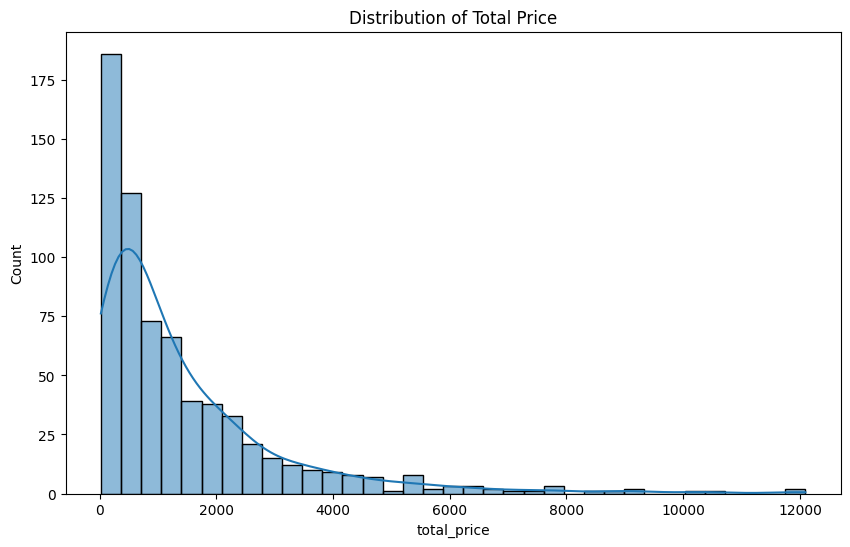

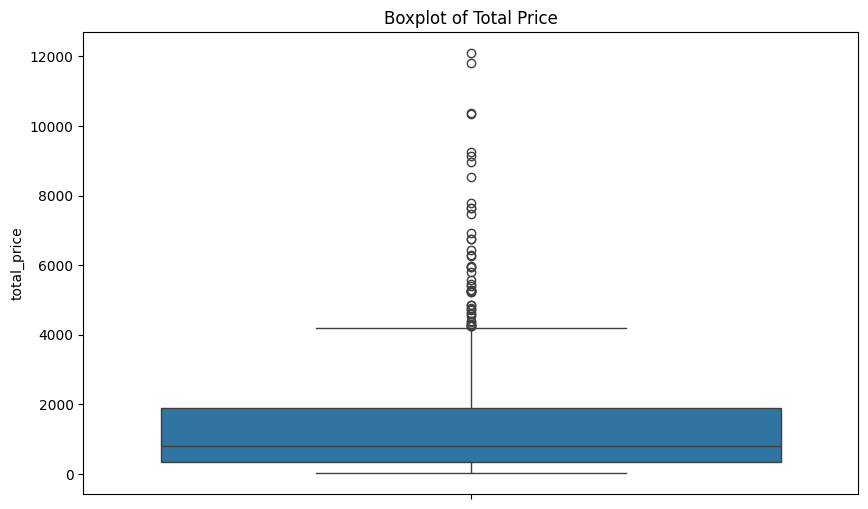

<ipython-input-11-c0e98a586815>:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data['total_price'], shade=True)


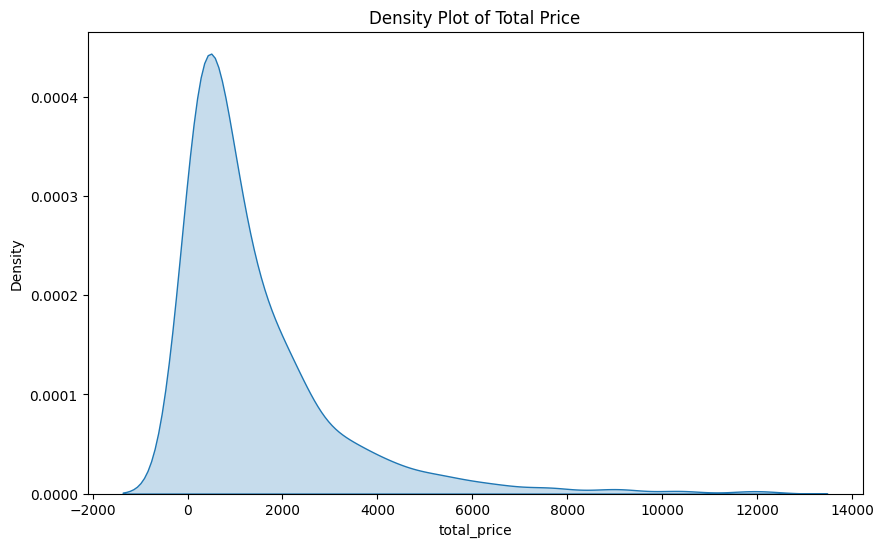

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Histogram for 'total_price'
plt.figure(figsize=(10, 6))
sns.histplot(data['total_price'], kde=True)
plt.title('Distribution of Total Price')
plt.show()

# Boxplot for 'total_price'
plt.figure(figsize=(10, 6))
sns.boxplot(y=data['total_price'])
plt.title('Boxplot of Total Price')
plt.show()

# Density Plot for 'total_price'
plt.figure(figsize=(10, 6))
sns.kdeplot(data['total_price'], shade=True)
plt.title('Density Plot of Total Price')
plt.show()


# Explanation:
### pd.to_numeric(errors='coerce'): Converts columns to numeric, setting any conversion errors to NaN.

### dropna(axis=1, how='all'): Drops columns that are entirely NaN after conversion.

### This approach ensures that only numeric data is considered for the correlation heatmap.

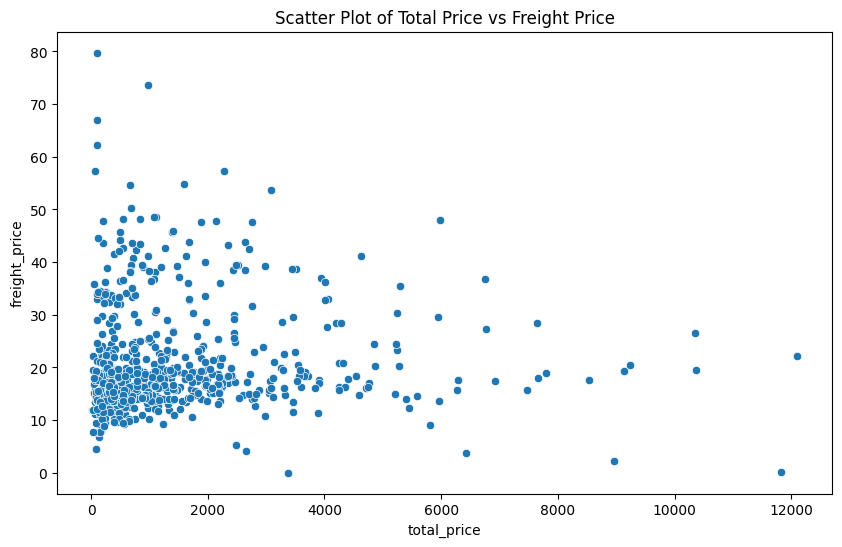

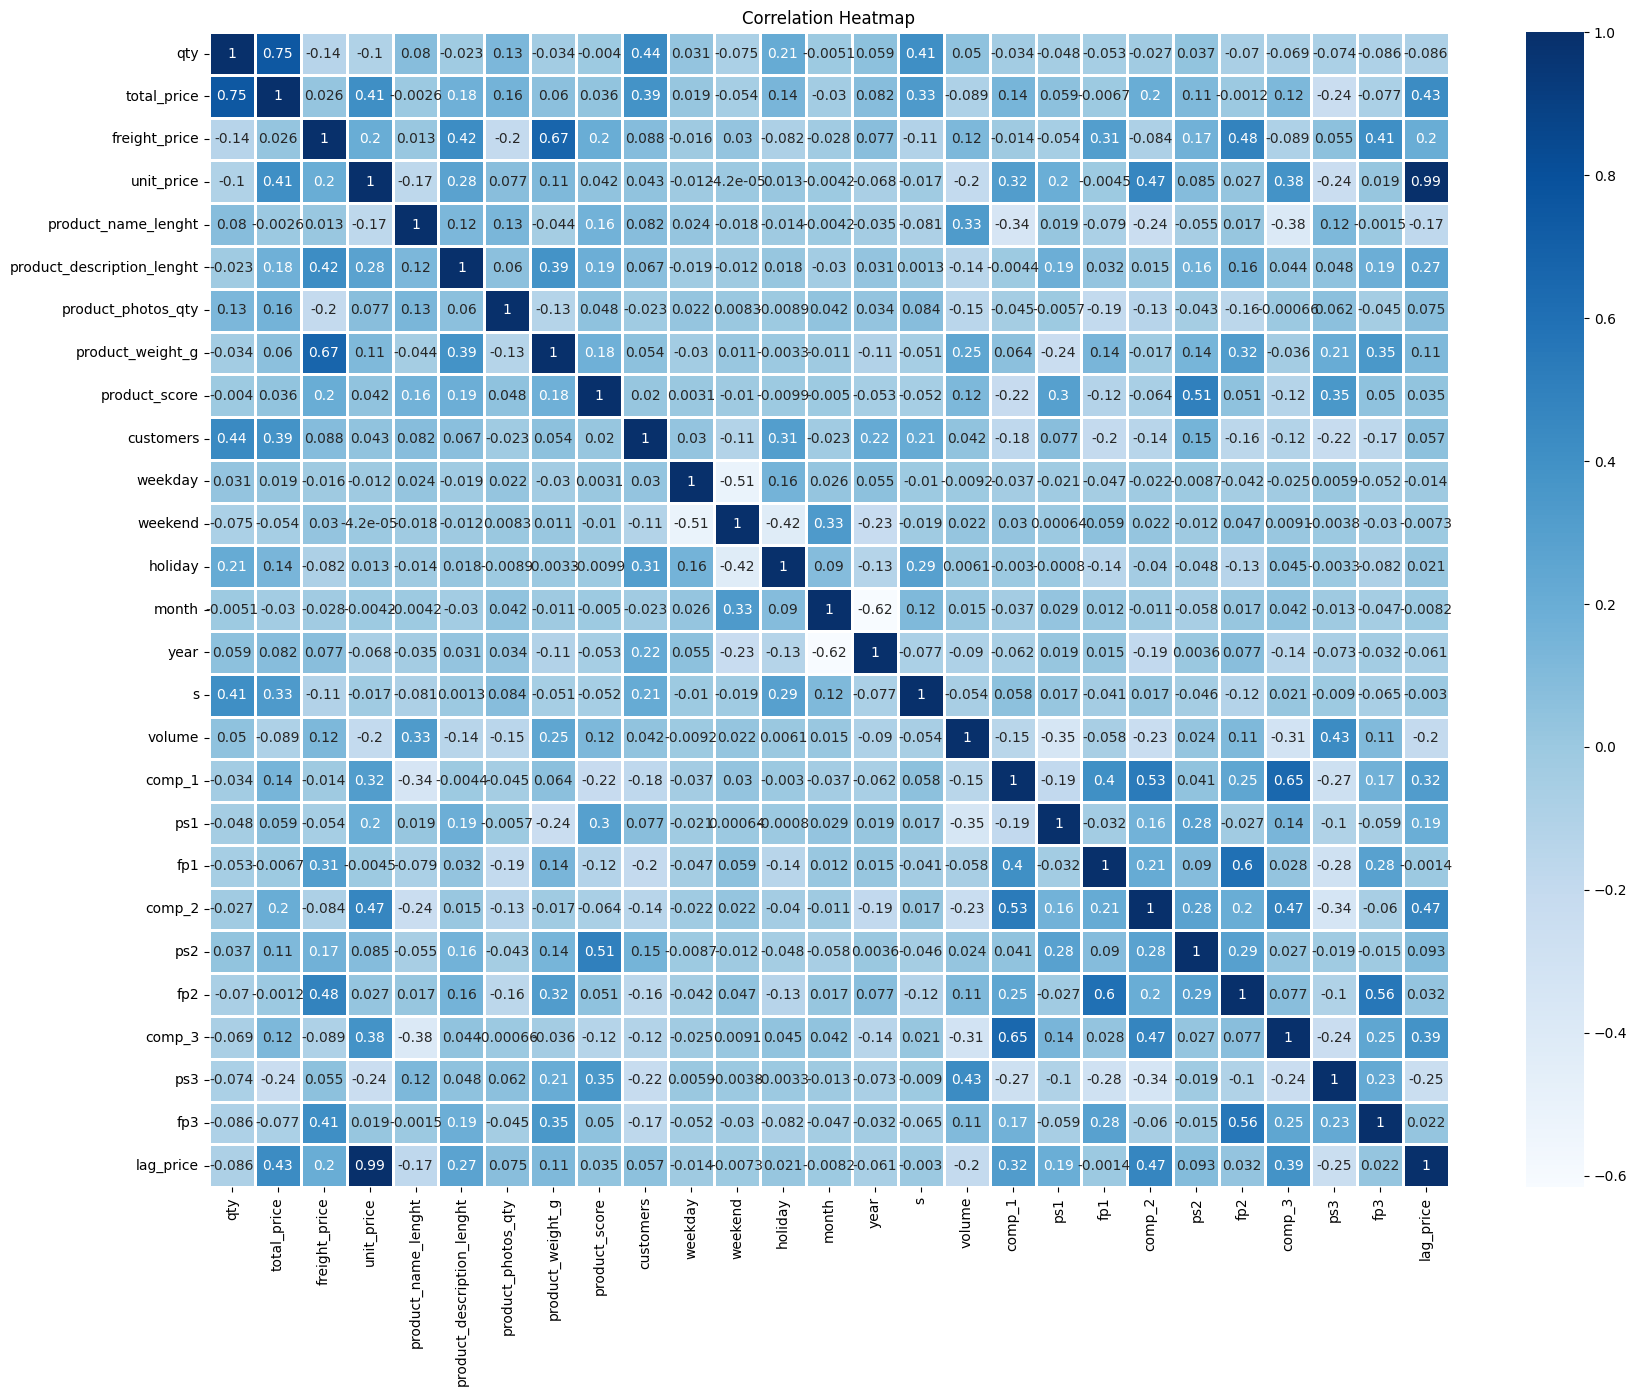

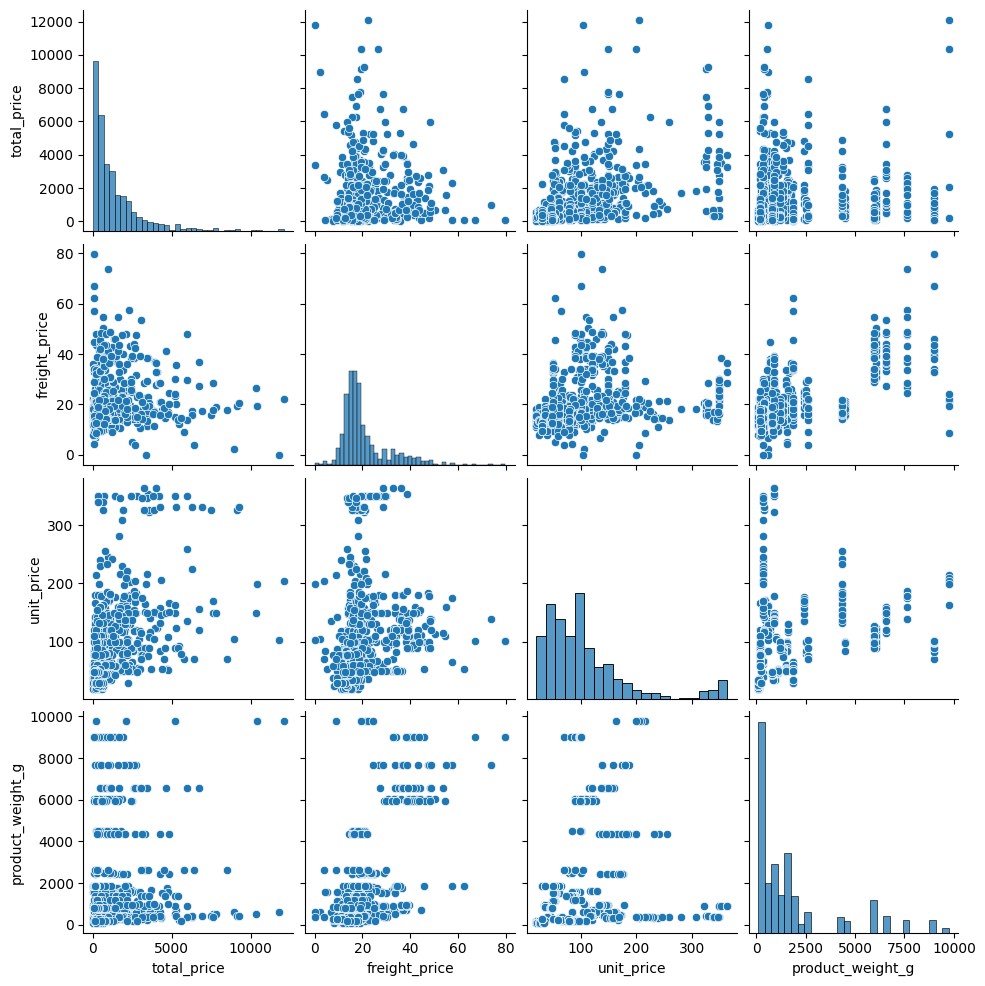

In [ ]:
# Scatter Plot between 'total_price' and 'freight_price'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_price', y='freight_price', data=data)
plt.title('Scatter Plot of Total Price vs Freight Price')
plt.show()

# Convert columns to numeric where possible, coercing errors to NaN
data_numeric = data.apply(pd.to_numeric, errors='coerce')

# Drop columns that cannot be converted to numeric
data_numeric = data_numeric.dropna(axis=1, how='all')

# Correlation Heatmap
plt.figure(figsize=(20, 15))
correlation_matrix = data_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', linewidths=1.0)
plt.title('Correlation Heatmap')
plt.show()

# Pair Plot
sns.pairplot(data[['total_price', 'freight_price', 'unit_price', 'product_weight_g']])
plt.show()


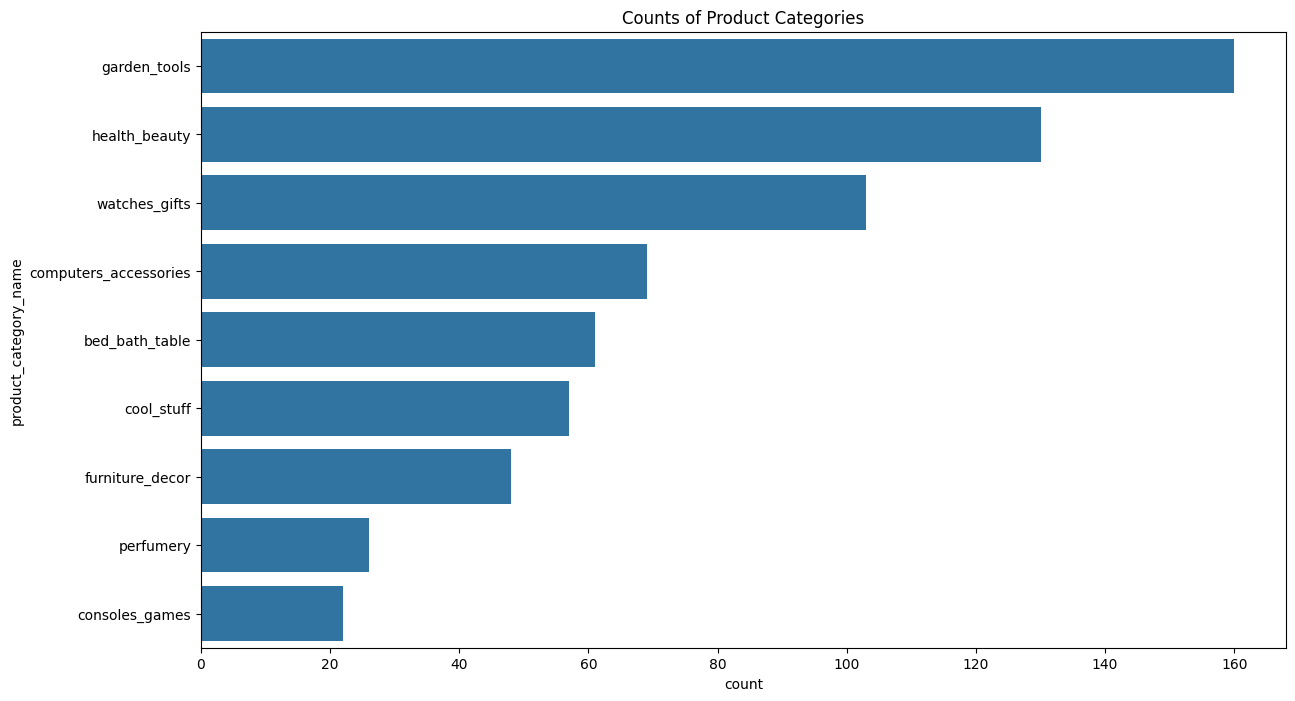

In [ ]:
# Bar Chart for 'product_category_name'
plt.figure(figsize=(14, 8))
sns.countplot(y='product_category_name', data=data, order=data['product_category_name'].value_counts().index)
plt.title('Counts of Product Categories')
plt.show()


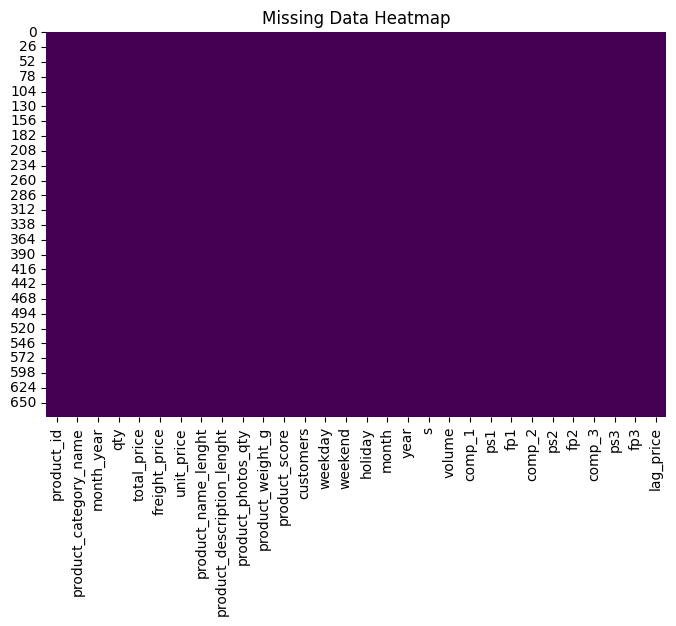

In [ ]:
# Heatmap to visualize missing data
plt.figure(figsize=(8, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# **Feature Engineering**

# 1. PolynomialFeatures
Concept:
PolynomialFeatures: This technique generates new features by taking polynomial combinations of the existing features. It helps to capture non-linear relationships between the features.

How It Works: For example, if you have two features
𝑥
 and
𝑦
, and set the degree to 2, PolynomialFeatures will generate:

𝑥

𝑦

𝑥
2

𝑦
2

𝑥
𝑦

Why It’s Useful:
Enhanced Feature Space: By generating polynomial features, the feature space is expanded, allowing the stochastic search algorithm to explore a more detailed search space.

Non-linear Relationships: Captures complex, non-linear relationships between features, which can lead to better optimization results.

# 2. StandardScaler
Concept:
StandardScaler: This scaling technique transforms features to have zero mean and unit variance. It’s a common preprocessing step in machine learning.

How It Works: It standardizes the features by removing the mean and scaling to unit variance.

Why It’s Useful:
Improved Convergence: Standardizing features ensures that they contribute equally to the optimization process, which can lead to faster and more stable convergence.

Normalization: Prevents features with larger scales from dominating the optimization process.

# 3. MinMaxScaler
Concept:
MinMaxScaler: This scaling technique transforms features by scaling them to a specific range, typically between 0 and 1.

How It Works: It scales each feature to a given range by dividing each feature by its maximum value minus its minimum value.

Why It’s Useful:
Uniform Range: Scales features to a uniform range, which can improve the performance of distance-based algorithms.

Handling Outliers: Reduces the impact of outliers by bringing all feature values to the same range.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler

# Creating interaction features
data['price_per_weight'] = data['total_price'] / data['product_weight_g']
data['freight_per_weight'] = data['freight_price'] / data['product_weight_g']

# Log transformation
data['log_total_price'] = np.log(data['total_price'] + 1)
data['log_freight_price'] = np.log(data['freight_price'] + 1)

# Generating polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(data[['total_price', 'freight_price', 'unit_price', 'product_weight_g']])
poly_features_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(['total_price', 'freight_price', 'unit_price', 'product_weight_g']))

# Scaling features
scaler = StandardScaler()
data[['total_price_scaled', 'freight_price_scaled', 'unit_price_scaled', 'product_weight_g_scaled']] = scaler.fit_transform(data[['total_price', 'freight_price', 'unit_price', 'product_weight_g']])

# Min-Max Scaling
min_max_scaler = MinMaxScaler()
data[['total_price_minmax', 'freight_price_minmax', 'unit_price_minmax', 'product_weight_g_minmax']] = min_max_scaler.fit_transform(data[['total_price', 'freight_price', 'unit_price', 'product_weight_g']])

# Binning the total price into 5 equal-width bins
data['total_price_binned'] = pd.cut(data['total_price'], bins=5, labels=False)

print(data.head())
print(poly_features_df.head())


  product_id product_category_name  month_year  qty  total_price  \
0       bed1        bed_bath_table  01-05-2017    1        45.95   
1       bed1        bed_bath_table  01-06-2017    3       137.85   
2       bed1        bed_bath_table  01-07-2017    6       275.70   
3       bed1        bed_bath_table  01-08-2017    4       183.80   
4       bed1        bed_bath_table  01-09-2017    2        91.90   

   freight_price  unit_price  product_name_lenght  product_description_lenght  \
0      15.100000       45.95                   39                         161   
1      12.933333       45.95                   39                         161   
2      14.840000       45.95                   39                         161   
3      14.287500       45.95                   39                         161   
4      15.100000       45.95                   39                         161   

   product_photos_qty  ...  log_freight_price  total_price_scaled  \
0                   2  ...         

# Define the Objective Function
### The objective function will sum the total_price column

In this code snippet, we're defining a function called objective_function that takes a DataFrame data as its input parameter. The function calculates the sum of the total_price column in the DataFrame and returns this sum as the objective value.

Why Consider an Objective Column?
In optimization problems, the objective function is a crucial component. It defines what we are trying to achieve or optimize. Here’s why we consider an objective column:

# Measure of Success:

The objective function serves as a quantitative measure of how good or bad a solution is.

In our case, the higher the total price, the better the solution.

# Guides the Optimization Process:

The objective function guides the search and optimization process.

It helps in evaluating different solutions and deciding which one is better.

# Defines the Goal:

It clearly defines the goal of the optimization.

Here, the goal is to maximize the total price from the dataset.

# Comparison Metric:

It provides a consistent metric to compare different solutions.

In each iteration of the algorithm, we use the objective function to compare the current solution with the candidate solution.

In [ ]:
# Defining the objective column
def objective_function(data):
    return data['total_price'].sum()

# Create an Initial Solution
### Randomly select a sample of the dataset

# Initial Solution:
The initial solution is the starting point for the optimization algorithm. It's the initial subset of data that we use to begin the search for the optimal solution.

In the context of the Stochastic Hill Climbing algorithm, the initial solution is a randomly selected subset of the dataset. This subset will be the starting point for generating new solutions (neighbors) in subsequent steps of the algorithm.

# Sample Size
Sample Size: The sample_size parameter determines the number of rows to be selected from the dataset to form the initial solution.

Why we need to use sample size: Using a sample size allows us to manage the computational complexity of the optimization process. Instead of working with the entire dataset, we work with a representative subset. This can be particularly useful when dealing with large datasets, as it reduces the computational cost and makes the optimization process more efficient.

# Importance of n and random_state
n: The parameter n=sample_size in the data.sample() function specifies the number of rows to be randomly sampled from the dataset.

Example: If sample_size=100, the function will return a new DataFrame containing 100 randomly selected rows from the original dataset.

random_state: The parameter random_state=1 ensures reproducibility of the random sampling process.

Why it's important: Setting a random_state ensures that every time you run this code, the same initial solution is generated. This is crucial for reproducibility and debugging, as it allows you to get consistent results across different runs.

Example: If you run the code today and next week with the same dataset and random_state, you will get the same initial solution both times.

In [ ]:
def initial_solution(data, sample_size=100):
  return data.sample(n=sample_size, random_state=1)

# Define the Neighborhood Function
### Create neighboring solutions by randomly replacing a row in the current solution.

# Neighborhood
Neighborhood: In optimization algorithms like Stochastic Hill Climbing, the neighborhood refers to a set of solutions that are similar to the current solution but have slight variations. These solutions are generated by making small changes to the current solution.

## Purpose: The neighborhood is used to explore the search space around the current solution to find potentially better solutions.

# Solution
Solution: In the context of this code, a solution is a subset of the dataset that represents a candidate for the optimal solution. Initially, this is formed by the initial solution.

## Example: If the dataset contains product information, a solution could be a subset of products selected from the dataset.

# Index to Replace
Index to Replace: This variable determines which row in the current solution will be replaced by a new row from the dataset. The random.randint(0, len(solution) - 1) generates a random index within the range of the current solution.

## Purpose: This random selection ensures that different parts of the current solution are modified in each iteration, helping to explore a variety of neighboring solutions.

# New Row
New Row: This is a randomly selected row from the original dataset that will replace the row at index_to_replace in the current solution. The random_state=random.randint(0, 1000) ensures that the selection is reproducible but varied.

## Purpose: Introducing a new row creates a variation in the current solution. This variation is crucial for exploring the search space and finding better solutions.

## Relationship to Stochastic Search
In Stochastic Hill Climbing, the algorithm iteratively explores the search space by generating and evaluating neighboring solutions. Here's how the explained concepts fit into this process:

# Current Solution: The algorithm starts with an initial solution.

## Generate Neighbor: A neighboring solution is generated by randomly modifying the current solution. This is done by selecting a row to replace (index to replace) and introducing a new row (new row) from the dataset.

## Evaluate Neighbor: The objective function is used to evaluate the quality of the neighboring solution.

## Update Solution: If the neighboring solution is better than the current solution, it becomes the new current solution.

## Iterate: This process is repeated for a specified number of iterations or until a stopping condition is met.

In [ ]:
def neighborhood(solution, data):
  neighbor = solution.copy()
  index_to_replace = random.randint(0, len(solution)-1)
  new_row = data.sample(n=1, random_state=random.randint(0,1000))
  neighbor.iloc[index_to_replace] = new_row.values[0]
  return neighbor

# Implementing the Stochastic Hill Climbing Algorithm

Absolutely! Let's break down the provided code step by step and explain the related concepts in detail.

### Stochastic Hill Climbing Algorithm

#### Code

```python
def stochastic_hill_climbing(data, iterations=1000, sample_size=100):
    current_solution = initial_solution(data, sample_size)
    current_value = objective_function(current_solution)
    
    for i in range(iterations):
        candidate_solution = neighborhood(current_solution, data)
        candidate_value = objective_function(candidate_solution)
        
        if candidate_value > current_value:
            current_solution = candidate_solution
            current_value = candidate_value
    
    return current_solution, current_value

# Execute the algorithm
final_solution, final_value = stochastic_hill_climbing(data)
print("Final Optimized Solution:")
print(final_solution)
print("Optimized Total Price:", final_value)
```

### Key Concepts and Explanation

#### Stochastic Hill Climbing

**Stochastic Hill Climbing** is an optimization algorithm that iteratively explores the search space by making random changes to the current solution (hence "stochastic") and moving to the new solution if it improves the objective function. The "hill climbing" part of the name comes from the idea of searching for a peak (maximum value) in the objective function.

### Why the Iterations?

**Iterations**: The number of times the algorithm will execute the process of generating a new candidate solution and evaluating it. More iterations increase the chances of finding a better solution, but also require more computation.

```python
for i in range(iterations):
```

- **Purpose**: To repeatedly explore the search space and improve the solution over time.
- **Example**: In the given code, `iterations=1000` means the algorithm will go through the process 1,000 times.

### Objective Function

**Objective Function**: A function used to evaluate the quality of a solution. It returns a value that indicates how good the solution is according to the specified criterion.

```python
def objective_function(data):
    return data['total_price'].sum()
```

- **Purpose**: To provide a quantitative measure of the solution's quality. In this case, it sums the `total_price` column to determine the total value.
- **Example**: If `total_price` values are [100, 200, 300], the objective function returns 600.

### Current Solution and Current Value

**Current Solution**: The solution currently being evaluated and improved upon.

```python
current_solution = initial_solution(data, sample_size)
```

**Current Value**: The value of the objective function for the current solution.

```python
current_value = objective_function(current_solution)
```

- **Purpose**: To keep track of the best solution found so far.
- **Example**: Initially, the current solution is a randomly selected subset of data, and the current value is the sum of the `total_price` for that subset.

### Candidate Solution and Candidate Value

**Candidate Solution**: A new solution generated by making a small change to the current solution (neighborhood).

```python
candidate_solution = neighborhood(current_solution, data)
```

**Candidate Value**: The value of the objective function for the candidate solution.

```python
candidate_value = objective_function(candidate_solution)
```

- **Purpose**: To explore new potential solutions and compare them with the current solution.
- **Example**: If the current solution changes slightly, the new configuration is the candidate solution, and its total price is the candidate value.

### Final Solution and Final Value

**Final Solution**: The best solution found after all iterations.

```python
final_solution, final_value = stochastic_hill_climbing(data)
```

**Final Value**: The value of the objective function for the final solution.

```python
print("Final Optimized Solution:")
print(final_solution)
print("Optimized Total Price:", final_value)
```

- **Purpose**: To present the optimal solution found by the algorithm.
- **Example**: After running through 1,000 iterations, the subset of data that provides the highest `total_price` is the final solution.

### How They Help the Model

- **Iterations**: Ensure the algorithm has enough chances to explore the search space.
- **Objective Function**: Provides a clear metric to evaluate and compare solutions.
- **Current and Candidate Solutions**: Allow the algorithm to iteratively improve upon the current best solution.
- **Final Solution and Value**: Represent the optimal result of the optimization process.

### Summary

The Stochastic Hill Climbing algorithm iteratively explores the search space by generating neighboring solutions and evaluating them using the objective function. If a candidate solution is better than the current solution, it becomes the new current solution. This process repeats for a specified number of iterations, resulting in the optimal solution found by the algorithm.

Let me know if you have any more questions or need further clarification!

In [ ]:
def stochastic_hill_climbing(data, iterations=1000, sample_size=100):
    current_solution = initial_solution(data, sample_size)
    current_value = objective_function(current_solution)

    for i in range(iterations):
        candidate_solution = neighborhood(current_solution, data)
        candidate_value = objective_function(candidate_solution)

        if candidate_value > current_value:
            current_solution = candidate_solution
            current_value = candidate_value

    return current_solution, current_value

# Execute the algorithm
final_solution, final_value = stochastic_hill_climbing(data)
print("Final Optimized Solution:")
print(final_solution)
print("Optimized Total Price:", final_value)


Final Optimized Solution:
     product_id product_category_name  month_year  qty  total_price  \
92      health2         health_beauty  01-04-2018   21       6930.0   
148        bed5        bed_bath_table  01-07-2017   59      12095.0   
159    watches5         watches_gifts  01-11-2017   12       2395.2   
460    watches2         watches_gifts  01-01-2018    8       1188.0   
453     health5         health_beauty  01-10-2017   10       3499.0   
..          ...                   ...         ...  ...          ...   
590        bed5        bed_bath_table  01-07-2017   59      12095.0   
329    garden10          garden_tools  01-03-2018   35       1886.5   
641    watches1         watches_gifts  01-11-2017   18       3139.8   
626  furniture2       furniture_decor  01-02-2018   44       3075.6   
400    watches4         watches_gifts  01-01-2018   44       4752.0   

     freight_price  unit_price  product_name_lenght  \
92       17.309048  330.000000                   60   
148      22

# **2. Genetic Algorithm**

In [ ]:
import numpy as np
import pandas as pd
import random

## Define the Fitness Function
#### The fitness function will evaluate how good a solution is. Here, we'll maximize the total_price.

Function Purpose: The initial_population function is designed to create an initial population of candidate solutions for a genetic algorithm. This is done by randomly sampling subsets from a given dataset.

Parameters:

data: The dataset from which samples will be drawn.

population_size: The number of candidate solutions (individuals) in the initial population.

sample_size: The number of rows to sample from the dataset for each individual in the population.

Ensuring Valid Sample Size: The function ensures that the sample size does not exceed the number of rows available in the dataset. If it does, the sample size is adjusted to match the total number of rows in the dataset.

Generating the Initial Population: The function generates the initial population by repeatedly sampling from the dataset. Each sample is a subset of rows from the dataset.

List Comprehension:

The list comprehension (for _ in range(population_size)) iterates population_size times.

The underscore (_) is a conventional placeholder used when the loop variable is not needed.

Each iteration involves sampling sample_size rows from the dataset, resetting the index of the sampled DataFrame for clean indexing.

Genetic Algorithm Context:

Initial Population: The set of candidate solutions at the start of the algorithm.

Population Size: The number of candidate solutions in each generation.

Sampling: Random sampling ensures diversity in the candidate solutions.

In [ ]:
def initial_population(data, population_size, sample_size):
    # Ensure sample size is not larger than available rows
    if sample_size > len(data):
        sample_size = len(data)
    return [data.sample(n=sample_size, random_state=random.randint(0, 1000)).reset_index(drop=True) for _ in range(population_size)]


In [ ]:
def fitness_function(solution):
  return solution['total_price'].sum()

## Initialize Population
#### Create an initial population of random solutions.

In [ ]:
def initial_population(data, population_size, sample_size):
  return [data.sample(n=sample_size,random_state=random.randint(0,1000)) for _ in range(population_size)]

## Selection
#### Select the best solutions based on their fitness scores.

In [ ]:
def selection(population, fitness_function):
    fitness_scores = [(solution, fitness_function(solution)) for solution in population]
    fitness_scores.sort(key=lambda x: x[1], reverse=True)
    selected_population = [solution for solution, score in fitness_scores[:len(population)//2]]
    return selected_population


## Crossover
#### Combine two parent solutions to create offspring.

In [ ]:
def crossover(parent1, parent2):
    crossover_point = random.randint(0, len(parent1) - 1)
    child = pd.concat([parent1.iloc[:crossover_point], parent2.iloc[crossover_point:]]).drop_duplicates().reset_index(drop=True)
    return child


## Mutation
#### Introduce variations by randomly altering genes in the offspring.


In [ ]:
def mutation(solution, data):
    if random.random() < 0.1:  # 10% chance of mutation
        index_to_replace = random.randint(0, len(solution) - 1)
        new_row = data.sample(n=1, random_state=random.randint(0, 1000))
        solution.iloc[index_to_replace] = new_row.values[0]
    return solution


# Genetic Algorithm
### Combine all steps to implement the Genetic Algorithm.

## The genetic_algorithm function is designed to find the best solution from a given dataset using a genetic algorithm. This type of algorithm is inspired by the process of natural selection and mimics the process of biological evolution. The function evolves a population of candidate solutions over a number of generations, improving their fitness with each iteration.

# Steps Involved:
## Initialize Population: The function starts by generating an initial population of candidate solutions using the initial_population function. This initial population is a set of randomly sampled subsets from the dataset.

## Iterate Over Generations:
The function then iterates over a specified number of generations. For each generation, it selects the best candidates from the current population based on a fitness function.

## Selection:
In each generation, a selection process is used to choose the best individuals (candidate solutions) from the population. These selected individuals are used to create the next generation.

# Crossover and Mutation:

## Crossover:
 The function performs crossover (a genetic operation) between pairs of selected individuals to create new offspring.

## Mutation:
 The function then applies mutation (another genetic operation) to these offspring to introduce variability and explore new solutions.

## Update Population:
 The new generation of individuals replaces the old population. The function continues this process for the specified number of generations.

## Find Best Solution:
 After all generations have been processed, the function identifies the best solution from the final population based on the fitness function. It then returns this best solution along with its fitness value.

In [ ]:
def genetic_algorithm(data, population_size=10, sample_size=50, generations=100):
    population = initial_population(data, population_size, sample_size)

    for generation in range(generations):
        population = selection(population, fitness_function)
        next_generation = []

        while len(next_generation) < population_size:
            parent1, parent2 = random.sample(population, 2)
            child = crossover(parent1, parent2)
            child = mutation(child, data)
            next_generation.append(child)

        population = next_generation
        best_solution = max(population, key=fitness_function)
        best_fitness = fitness_function(best_solution)
        print(f"Generation {generation+1}: Best Fitness = {best_fitness}")

    return best_solution, best_fitness

# Execute the Genetic Algorithm
best_solution, best_fitness = genetic_algorithm(data)
print("Best Solution Found:")
print(best_solution)
print("Best Fitness:", best_fitness)


Generation 1: Best Fitness = 91002.77
Generation 2: Best Fitness = 97732.97
Generation 3: Best Fitness = 101367.54
Generation 4: Best Fitness = 97721.53000000001
Generation 5: Best Fitness = 100281.05
Generation 6: Best Fitness = 101367.54
Generation 7: Best Fitness = 101367.54
Generation 8: Best Fitness = 95785.73999999999
Generation 9: Best Fitness = 95785.73999999999
Generation 10: Best Fitness = 95785.73999999999
Generation 11: Best Fitness = 95785.73999999999
Generation 12: Best Fitness = 95785.73999999999
Generation 13: Best Fitness = 95968.79000000001
Generation 14: Best Fitness = 97030.92
Generation 15: Best Fitness = 101875.94
Generation 16: Best Fitness = 101875.94
Generation 17: Best Fitness = 102566.23999999999
Generation 18: Best Fitness = 105290.32
Generation 19: Best Fitness = 105290.32
Generation 20: Best Fitness = 105290.32
Generation 21: Best Fitness = 105667.81
Generation 22: Best Fitness = 105667.81
Generation 23: Best Fitness = 105667.81
Generation 24: Best Fitness

# **3. Grediant Search algorithm**

# Gradient Descent Algorithm
### Gradient Descent is an iterative optimization algorithm used to find the minimum value of a function. It is commonly used in machine learning to optimize models by minimizing a loss function.

## Steps Involved:
### Initialize Parameters:
Start with initial values for the parameters (weights and biases).

## Compute Loss:
Calculate the loss using the current parameters.

## Compute Gradients:
Calculate the gradient of the loss function with respect to each parameter.

## Update Parameters:
Adjust the parameters in the opposite direction of the gradients.

## Repeat:
Continue this process until the loss converges to a minimum value.

In [ ]:
# Load dataset
data = pd.read_csv('retail_price.csv')  # Replace with your dataset path

# Features (X) and Target (y)
X = data[['qty', 'freight_price', 'unit_price', 'product_score', 'customers']].values  # Select relevant features
y = data['total_price'].values  # Target variable

# Add a column of ones to include the bias term (intercept) in the model
X = np.c_[np.ones(X.shape[0]), X]


# Initialize Parameters:

In [ ]:
# Initialize weights
weights = np.zeros(X.shape[1])

# Define Hyperparameters:
## Learning Rate:
 Determines the step size for each iteration. A smaller learning rate means slower convergence but higher precision, while a larger learning rate speeds up convergence but may overshoot the optimal solution.

## Number of Iterations:
The number of times the algorithm will update the weights.

In [ ]:
# Hyperparameters
learning_rate = 0.01
num_iterations = 1000

# Define Cost Function (Mean Squared Error):

In [ ]:
def compute_cost(X, y, weights):
    m = len(y)
    predictions = X.dot(weights)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost


# Define Gradient Descent Function:

## Compute Predictions: Calculate the predicted values using the current weights.

## Compute Gradients: Calculate the gradient of the cost function with respect to each weight.

## Update Weights: Adjust the weights in the opposite direction of the gradient by a step size defined by the learning rate.

## Store Cost: Store the cost value for each iteration to track the optimization process.

In [ ]:
def gradient_descent(X, y, weights, learning_rate, num_iterations):
    m = len(y)
    cost_history = np.zeros(num_iterations)

    for i in range(num_iterations):
        # Compute predictions
        predictions = X.dot(weights)

        # Compute gradients
        gradients = (1 / m) * X.T.dot(predictions - y)

        # Update weights
        weights -= learning_rate * gradients

        # Store cost
        cost_history[i] = compute_cost(X, y, weights)

        # Print cost every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost_history[i]}")

    return weights, cost_history


# Weights:
### Weights are the parameters of the model that are adjusted during the training process to minimize the cost function. Each weight corresponds to a feature in the dataset, including the bias term. Optimizing these weights allows the model to make accurate predictions.

# Learning Rate:
### The learning rate is a hyperparameter that determines the step size for each iteration of the gradient descent algorithm. It controls how much the weights are adjusted with respect to the gradient. A suitable learning rate ensures convergence to the optimal solution.

# Cost History:
### Cost history is an array that stores the cost value (Mean Squared Error) for each iteration of the gradient descent algorithm. Tracking the cost history helps in monitoring the optimization process and ensuring that the cost is decreasing, indicating that the model is learning.

# Run Gradient Descent:

In [ ]:
# Run Gradient Descent
final_weights, cost_history = gradient_descent(X, y, weights, learning_rate, num_iterations)


Iteration 0: Cost 80553908386.05742
Iteration 100: Cost inf
Iteration 200: Cost nan
Iteration 300: Cost nan
Iteration 400: Cost nan
Iteration 500: Cost nan
Iteration 600: Cost nan
Iteration 700: Cost nan
Iteration 800: Cost nan
Iteration 900: Cost nan


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-31-109559a85c53>:4: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)


# Make Predictions:

In [ ]:
# Make predictions
predictions = X.dot(final_weights)

# Evaluate the Model:

In [ ]:
# Calculate Mean Squared Error
mse = compute_cost(X, y, final_weights)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: nan


# **4. Linear Programming**

In [ ]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 82.6 MB/s eta 0:00:00


# Concepts Explained:
## 1. LpProblem:
### Purpose: It initializes an optimization problem. You can specify the objective (maximize or minimize) and add constraints.

### Role in Linear Programming: It sets up the framework for defining and solving the Linear Programming problem.

## 2. LpMaximize / LpMinimize:
### Purpose: These constants specify the goal of the optimization problem. LpMaximize aims to maximize the objective function, while LpMinimize aims to minimize it.

### Role in Linear Programming: They define the direction of optimization.

## 3. LpVariable:
### Purpose: It defines the decision variables in the Linear Programming problem. You can set lower and upper bounds on the variables.

### Role in Linear Programming: They represent the variables that will be adjusted to optimize the objective function.

## 4. LpStatus:
### Purpose: This dictionary provides a human-readable status of the optimization problem's solution (e.g., Optimal, Infeasible).

### Role in Linear Programming: It helps interpret the result of the optimization process.

## 5. Coefficients:
### Purpose: They represent the impact of each decision variable on the objective function. They quantify how much each variable contributes to the goal (e.g., profit, cost).

### Role in Linear Programming: They define the relationship between decision variables and the objective function.

## 6. Status in Linear Programming:
### Purpose: It indicates the outcome of the optimization process. Common statuses include:

# Optimal: The problem has an optimal solution.

# Infeasible: No solution satisfies all constraints.

# Unbounded: The objective function can be increased indefinitely.

### Role in Linear Programming: It helps understand whether the optimization was successful and whether the solution is valid.

In [ ]:
import pandas as pd
from pulp import LpMaximize, LpProblem, LpVariable, LpStatus

# Initializing Model

## LpProblem:
This function initializes the Linear Programming model. It creates an instance of an optimization problem.

## name:
A string that names the problem.

## sense:
Specifies whether the goal is to maximize (LpMaximize) or minimize (LpMinimize) the objective function.

In [ ]:
model = LpProblem(name="maximizing-total-price", sense=LpMaximize)

# Define Decision Variables:

## lowBound:
Sets a lower bound on the variable. Here, it ensures that the variables are non-negative (≥ 0).

In [ ]:
qty = LpVariable(name="qty", lowBound=0)
freight_price = LpVariable(name="freight_price", lowBound=0)
unit_price = LpVariable(name="unit_price", lowBound=0)
product_score = LpVariable(name="product_score", lowBound=0)
customers = LpVariable(name="customers", lowBound=0)

# Define Objective Function Coefficients:

# Coefficients:
### These are numerical values that represent the contribution of each decision variable to the objective function. They quantify the impact of each variable on the objective function.

In [ ]:
c0 = 1  # bias term
c1 = 1  # coefficient for qty
c2 = 1  # coefficient for freight_price
c3 = 1  # coefficient for unit_price
c4 = 1  # coefficient for product_score
c5 = 1  # coefficient for customers

# Define the Objective Function:

The objective function is defined to maximize the sum of the coefficients multiplied by their respective decision variables.

In [ ]:
model += (c0 +
          c1 * qty +
          c2 * freight_price +
          c3 * unit_price +
          c4 * product_score +
          c5 * customers)


# Add Constraints:

## Constraints are added to ensure that all decision variables are non-negative. In real problems, constraints would reflect limitations on resources, capacities, or other restrictions.

In [ ]:
model += (qty >= 0)
model += (freight_price >= 0)
model += (unit_price >= 0)
model += (product_score >= 0)
model += (customers >= 0)

# Solve the Model:

## The model is solved to find the optimal values of the decision variables that maximize the objective function. The solve function runs the optimization solver.

In [ ]:
status = model.solve()

# Get Results:

## Status:
 This indicates whether the optimization problem was successfully solved. The LpStatus dictionary provides a human-readable description of the status.

## Optimal value:
 This is the maximum (or minimum) value of the objective function achieved by the optimal solution.

## Decision Variable Values:
These are the optimal values for the decision variables.

In [ ]:
print(f"Status: {model.status}, {LpStatus[model.status]}")
print(f"Optimal value: {model.objective.value()}")
print(f"qty = {qty.value()}")
print(f"freight_price = {freight_price.value()}")
print(f"unit_price = {unit_price.value()}")
print(f"product_score = {product_score.value()}")
print(f"customers = {customers.value()}")

Status: -2, Unbounded
Optimal value: 1.0
qty = 0.0
freight_price = 0.0
unit_price = 0.0
product_score = 0.0
customers = 0.0


# **5. Integer Programming**

In [ ]:
import pandas as pd
from pulp import LpMaximize, LpProblem, LpVariable, LpStatus

In [ ]:
def setup_model(name, integer=False):
    # Initialize the model
    model = LpProblem(name=name, sense=LpMaximize)

    # Define decision variables
    if integer:
        qty = LpVariable(name="qty", lowBound=0, cat='Integer')
        freight_price = LpVariable(name="freight_price", lowBound=0)
        unit_price = LpVariable(name="unit_price", lowBound=0)
        product_score = LpVariable(name="product_score", lowBound=0, cat='Integer')
        customers = LpVariable(name="customers", lowBound=0, cat='Integer')
    else:
        qty = LpVariable(name="qty", lowBound=0)
        freight_price = LpVariable(name="freight_price", lowBound=0)
        unit_price = LpVariable(name="unit_price", lowBound=0)
        product_score = LpVariable(name="product_score", lowBound=0)
        customers = LpVariable(name="customers", lowBound=0)

    # Objective function coefficients
    c0 = 1  # bias term
    c1 = 1  # coefficient for qty
    c2 = 1  # coefficient for freight_price
    c3 = 1  # coefficient for unit_price
    c4 = 1  # coefficient for product_score
    c5 = 1  # coefficient for customers

    # Define the objective function
    model += (c0 +
              c1 * qty +
              c2 * freight_price +
              c3 * unit_price +
              c4 * product_score +
              c5 * customers)

    # Add constraints to the model
    model += (qty >= 0)
    model += (freight_price >= 0)
    model += (unit_price >= 0)
    model += (product_score >= 0)
    model += (customers >= 0)

    return model, qty, freight_price, unit_price, product_score, customers


In [ ]:
def solve_and_print(model, qty, freight_price, unit_price, product_score, customers):
    # Solve the model
    status = model.solve()

    # Get results
    print(f"Status: {model.status}, {LpStatus[model.status]}")
    print(f"Optimal value: {model.objective.value()}")
    print(f"qty = {qty.value()}")
    print(f"freight_price = {freight_price.value()}")
    print(f"unit_price = {unit_price.value()}")
    print(f"product_score = {product_score.value()}")
    print(f"customers = {customers.value()}")


In [ ]:
print("\nInteger Programming:")
ip_model, qty, freight_price, unit_price, product_score, customers = setup_model("maximizing-total-price-integer", integer=True)
solve_and_print(ip_model, qty, freight_price, unit_price, product_score, customers)



Integer Programming:
Status: -2, Unbounded
Optimal value: 1.0
qty = 0.0
freight_price = 0.0
unit_price = 0.0
product_score = 0.0
customers = 0.0


Sure! Let's delve into Integer Programming, its concepts, and its key distinctions from Linear Programming.

### **Integer Programming Concept:**

**Integer Programming (IP)** is an optimization technique similar to Linear Programming (LP), but with the additional constraint that some or all of the decision variables must be integers. This makes IP particularly useful for problems where the solution requires discrete units, such as scheduling, allocation, and resource management.

### **Key Concepts:**

1. **Objective Function:**
   - **Definition:** Just like in Linear Programming, the objective function in Integer Programming is a linear equation that needs to be maximized or minimized.
   - **Form:** `Maximize (or Minimize) Z = c0 + c1*x1 + c2*x2 + ... + cn*xn`
   - **Purpose:** This function represents the goal of the optimization, such as maximizing profit or minimizing cost.

2. **Decision Variables:**
   - **Definition:** Variables that affect the objective function.
   - **Linear Programming:** In LP, decision variables can take any continuous values within the given bounds.
   - **Integer Programming:** In IP, decision variables are restricted to integer values. For example, in a scheduling problem, you can't allocate half a worker to a task.

3. **Constraints:**
   - **Definition:** Linear inequalities or equations that the solution must satisfy.
   - **Purpose:** These represent the limitations or requirements of the problem, such as resource capacities, budget limits, or time constraints.
   - **Form:** `a1*x1 + a2*x2 + ... + an*xn ≤ b`

### **Additional Features in Integer Programming:**

1. **Integer Constraints:**
   - **Definition:** Additional constraints that require some or all decision variables to be integers.
   - **Example:** In scheduling, `number_of_workers` must be an integer (you cannot have 2.5 workers).
   - **Form:** `x1, x2, ..., xn ∈ Integers`

2. **Binary Variables:**
   - **Definition:** A special case of integer variables that can only take values 0 or 1.
   - **Purpose:** Used to model yes/no decisions or selection problems.
   - **Example:** In a facility location problem, `x = 1` if a facility is built at a location, otherwise `x = 0`.

3. **Mixed-Integer Programming (MIP):**
   - **Definition:** A type of Integer Programming where some variables are integers and others are continuous.
   - **Purpose:** Provides flexibility in modeling problems that involve both discrete and continuous decisions.
   - **Example:** In investment planning, the number of units produced might be an integer, while the amount of raw material used might be continuous.

### **Comparison with Linear Programming:**

| Feature                | Linear Programming (LP)     | Integer Programming (IP)    |
|------------------------|-----------------------------|-----------------------------|
| **Decision Variables** | Continuous values           | Integer values              |
| **Objective Function** | Linear                      | Linear                      |
| **Constraints**        | Linear inequalities/equations | Linear inequalities/equations |
| **Solutions**          | Continuous                  | Discrete/Integer            |
| **Special Cases**      | -                           | Binary Variables, MIP       |
| **Complexity**         | Relatively easier to solve  | More complex to solve due to combinatorial nature |

### **Why Use Integer Programming?**

1. **Discrete Decisions:**
   - Many real-world problems involve decisions that are inherently discrete (e.g., number of trucks, number of workers).
   
2. **Binary Decisions:**
   - Binary variables are essential for modeling yes/no or on/off decisions (e.g., whether to build a facility, whether to include a specific project).

3. **Improved Realism:**
   - Integer constraints make models more realistic by accurately reflecting the nature of the problem (e.g., you can’t produce a fractional number of products).

### **Example Implementation:**

In the code example provided earlier, we used the `cat='Integer'` parameter in the `LpVariable` function to enforce integer constraints in Integer Programming. Here’s a quick snippet for reference:

```python
# Define decision variables for Integer Programming
qty = LpVariable(name="qty", lowBound=0, cat='Integer')
freight_price = LpVariable(name="freight_price", lowBound=0)
unit_price = LpVariable(name="unit_price", lowBound=0)
product_score = LpVariable(name="product_score", lowBound=0, cat='Integer')
customers = LpVariable(name="customers", lowBound=0, cat='Integer')
```

In conclusion, Integer Programming is an extension of Linear Programming that incorporates integer constraints, making it suitable for problems requiring discrete decisions. Its additional features, such as binary variables and mixed-integer programming, provide powerful tools for modeling and solving a wide range of optimization problems.


# **6. Multi-Armed bandit Algorithm**

# Key Concepts
## Multi-Armed Bandit Problem:

#### A problem in which a gambler must decide which slot machine (arm) to play to maximize their reward. Each arm has an unknown probability of giving a reward.

### Exploration vs. Exploitation:

### Exploration:
 Trying different arms to gather information about their reward probabilities.

### Exploitation:
 Using the gathered information to select the arm with the highest known reward.

## Epsilon-Greedy Algorithm:

#### A simple strategy where with probability ε (epsilon), a random arm is selected (exploration), and with probability 1-ε, the arm with the highest estimated reward is selected (exploitation).

#### Upper Confidence Bound (UCB) Algorithm:

This algorithm selects the arm with the highest upper confidence bound on the expected reward, balancing exploration and exploitation based on uncertainty.

## Thompson Sampling:

#### A Bayesian approach that samples from the posterior distribution of the reward probabilities and selects the arm with the highest sampled reward.

## Workflow
#### Load the Dataset:

#### Load the dataset containing information about the products and their corresponding rewards (e.g., total price).

## Initialize the Bandit Algorithm:

#### Define the number of arms (products) and set the parameters for the bandit algorithm.

### Simulate the Multi-Armed Bandit:

#### Iterate through the dataset, select an arm based on the algorithm, observe the reward, and update the algorithm.

## Evaluate the Model:

#### Assess the performance of the bandit algorithm by analyzing the cumulative rewards and the distribution of arm selections.

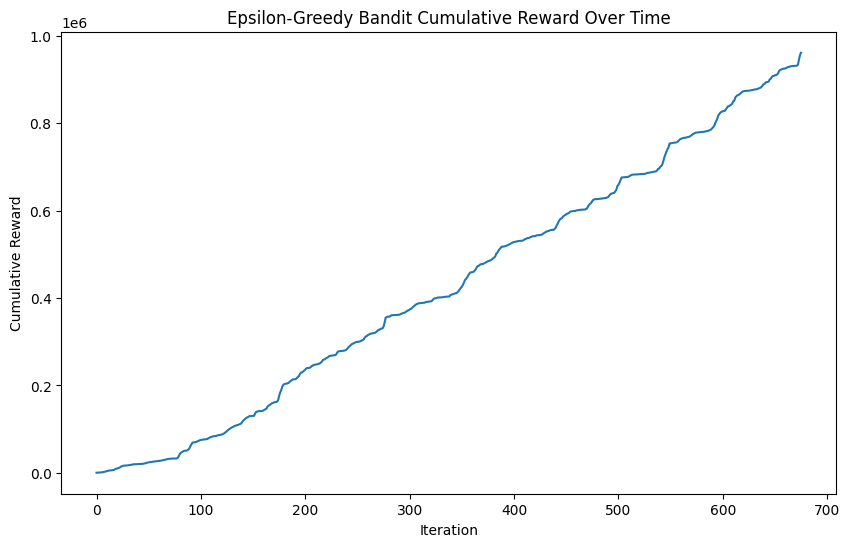

Final Counts: [ 10.   1.   4.   0.  23.   3.   0.  34.   3.   4.  11. 392.   0.   3.
   8.   0.   2.   8.   8.   4.   6.   2.   6.  31.   0.   9.   0.   0.
  23.   1.   2.   1.  16.   0.   6.   0.   1.   0.   3.  32.   1.   0.
   4.   2.   1.   0.   5.   1.   1.   2.   1.   1.]
Final Values: [ 303.847        78.          821.1125        0.         1442.68130435
 1394.71333333    0.          452.07470588  407.71       1112.95
  581.35090909 1635.3377551     0.          836.97333333  443.9225
    0.         1317.8        1217.595      1327.285      1375.9275
 1149.85166667  264.65       1559.76166667 1535.60709677    0.
 1271.92111111    0.            0.         1563.90956522  219.8
  319.595        95.8        1426.746875      0.         1452.
    0.          167.            0.         1433.43333333 1520.47625
  589.9           0.          870.365      1041.57        140.
    0.         1391.96        598.8         101.         1280.76
  117.98        872.1       ]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('retail_price.csv')

# Define the Epsilon-Greedy Bandit class
class EpsilonGreedyBandit:
    def __init__(self, k, epsilon):
        self.k = k  # Number of arms (products)
        self.epsilon = epsilon  # Exploration probability
        self.counts = np.zeros(k)  # Counts of pulls for each arm
        self.values = np.zeros(k)  # Estimated values for each arm
        self.cumulative_reward = 0  # Total cumulative reward

    def select_arm(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)  # Explore
        else:
            return np.argmax(self.values)  # Exploit

    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        # Update the estimated value of the chosen arm
        new_value = ((n - 1) / n) * value + (1 / n) * reward
        self.values[arm] = new_value
        self.cumulative_reward += reward

# Initialize the bandit
product_ids = data['product_id'].unique()
k = len(product_ids)
epsilon = 0.1
bandit = EpsilonGreedyBandit(k, epsilon)

# Simulate the multi-armed bandit algorithm
rewards = []
for index, row in data.iterrows():
    # Select an arm (product)
    arm = bandit.select_arm()

    # Get the reward (total_price) for the selected arm
    selected_product = product_ids[arm]
    reward = row['total_price']

    # Update the bandit with the observed reward
    bandit.update(arm, reward)

    # Store the cumulative reward
    rewards.append(bandit.cumulative_reward)

# Evaluate the model
plt.figure(figsize=(10, 6))
plt.plot(rewards)
plt.xlabel('Iteration')
plt.ylabel('Cumulative Reward')
plt.title('Epsilon-Greedy Bandit Cumulative Reward Over Time')
plt.show()

# Print final counts and values
print("Final Counts:", bandit.counts)
print("Final Values:", bandit.values)
